In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import logsumexp, comb
from scipy import integrate


C:\Users\apeti\AppData\Local\Temp\ipykernel_20192\2908448894.py:10: RuntimeWarning: divide by zero encountered in log
  return (1-x)*np.log(1-x)+x*np.log(x)
C:\Users\apeti\AppData\Local\Temp\ipykernel_20192\2908448894.py:10: RuntimeWarning: invalid value encountered in multiply
  return (1-x)*np.log(1-x)+x*np.log(x)


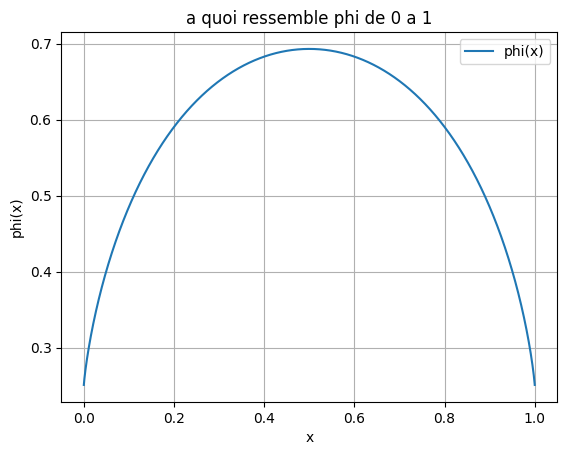

In [49]:
N = 100000 #nb de sites
T = 2 #température en Kelvin
J0 = 1 # 
B0 = 10**(-12)  #champ magnétique
J = J0/N # J normalisé
B = B0  #B normalisé


def xi(x) : 
    return (1-x)*np.log(1-x)+x*np.log(x) 

def energie(x) : 
    return (J0*(2*x-1)**2 - 2*B0*(2*x-1))/(2*T)

def phi(x) :
    return - xi(x)+energie(x)

fig = plt.figure()

X = np.linspace(0, 1, 10000)
Y_xi= - xi(X)
Y_energie =   energie(X)
Y_phi =  phi(X)

plt.plot(X, Y_phi, label = 'phi(x)')
#plt.plot(X, Y_xi, linestyle = '--', label = 'xi(x)')
#plt.plot(X, Y_energie, linestyle = '--', label = 'energie(x)')
plt.xlabel('x')
plt.ylabel('phi(x)')
plt.title('a quoi ressemble phi de 0 a 1')
plt.legend()
plt.grid('True')
plt.show()

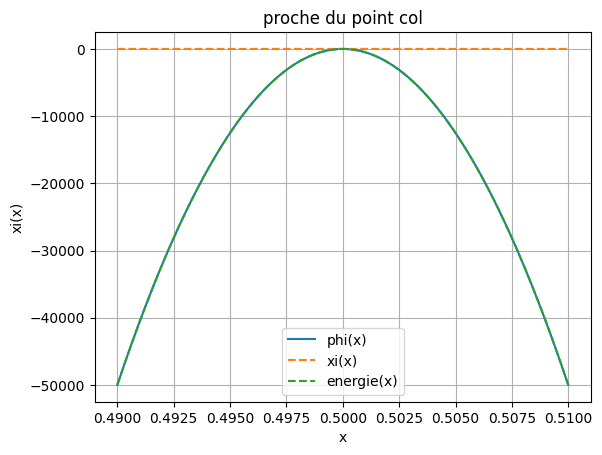

In [18]:
X = np.linspace(0.49, 0.51, 10000)

plt.plot(X, Y_phi, label = 'phi(x)')
plt.plot(X, Y_xi, linestyle = '--', label = 'xi(x)')
plt.plot(X, Y_energie, linestyle = '--', label = 'energie(x)')
plt.xlabel('x')
plt.ylabel('xi(x)')
plt.title('proche du point col')
plt.legend()
plt.grid('True')
plt.show()

In [ ]:
N = 50  # nb de sites
T = 1    # température en Kelvin
J = 1    # cst de couplage
B = 1    # champ magnétique
J0 = J * N  # J normalisé
B0 = B      # B normalisé


X = np.linspace(0.01, 0.99, 10000)

def integrande(x): 
    return 1/np.sqrt(x*(1-x)) * np.exp(N*(phi(x)))

Y_integrande = integrande(X)

plt.figure()
plt.plot(X, Y_integrande, 'r-', label=f'integrande(x), N = {N}')
plt.xlabel('x')
plt.ylabel('integrande(x)')
plt.xlim(0.01, 0.99)
plt.title('Intégrande')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\apeti\AppData\Local\Temp\ipykernel_60836\524914645.py:20: RuntimeWarning: overflow encountered in exp
  return 1/np.sqrt(x*(1-x)) * np.exp(N*(phi(x)))
C:\Users\apeti\AppData\Local\Temp\ipykernel_60836\524914645.py:20: RuntimeWarning: overflow encountered in multiply
  return 1/np.sqrt(x*(1-x)) * np.exp(N*(phi(x)))


ValueError: arange: cannot compute length

<Figure size 640x480 with 1 Axes>

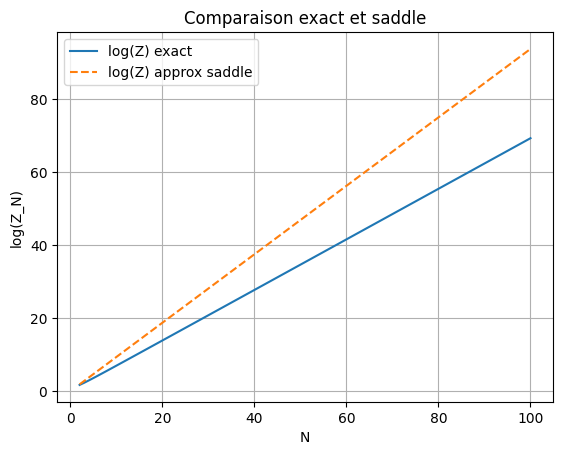

In [86]:
#Z_N en fonction de N

J0 = 1.0  
B0 = 1.0  
T = 1.0         

def xi(x):
    return x*np.log(x) + (1-x)*np.log(1-x)

def energie(x):
    return (J0*(2*x-1)**2 + 2*B0*(2*x-1)) / (2.0*T)

def phi(x, n):
    return -xi(x) - energie(x)

def dphi(x, n, h=1e-7): #resultat numerique
    return (phi(x+h, n) - phi(x-h, n)) / (2*h)

def ddphi(x, n): #calcul analytique
    return -1.0/(x*(1-x)) + 4.0*J0/(T*n)

#Z_N exact
def Z_N_exact_log(n):
    log_terms = []
    for k in range(0, n+1):
        x = k / n
        log_comb = np.log(comb(n, k, exact=False))
        exp_term = energie(x)
        log_terms.append(log_comb + exp_term)
    return - J0/(2.0*T*n) + logsumexp(log_terms)


#Z_N approximé sous forme intégrale
def Z_N_integral_log(n, n_grid=2001):
    X_grid = np.linspace(1e-8, 1-1e-8, n_grid)
    phi_vals = np.array([phi(x, n) for x in X_grid])
    log_integrand = -0.5*np.log(X_grid*(1-X_grid)) + n*phi_vals
    dx = X_grid[1] - X_grid[0]
    log_int = logsumexp(log_integrand + np.log(dx))
    # préfacteur global
    log_pref = - J0/(2.0*T*n) + 0.5*np.log(n/(2.0*np.pi))
    return log_pref + log_int

# Z_N approximé avec saddle-point method
def Z_N_approx_log(n):
    X_col = brentq(lambda x: dphi(x, n), 0.01, 0.99, maxiter=200)
    return -J0/(2.0*T*n) + n*phi(X_col, n)  -0.5*np.log(X_col*(1-X_col))- 0.5*np.log(-ddphi(X_col, n))

#plot

NN = np.arange(2, 101)
Y_exact_log = [Z_N_exact_log(n) for n in NN]
Y_approx_log = [Z_N_approx_log(n) for n in NN]
Y_integrale_log = [Z_N_integral_log(n) for n in NN]

#plt.plot(NN, Y_integrale_log, label='log(Z) intégrale')
plt.plot(NN, Y_exact_log,  label='log(Z) exact')
plt.plot(NN, Y_approx_log, '--', label='log(Z) approx saddle')
plt.xlabel('N')
plt.ylabel('log(Z_N)')
plt.title('Comparaison exact et saddle')
plt.legend()
plt.grid(True)
plt.show()


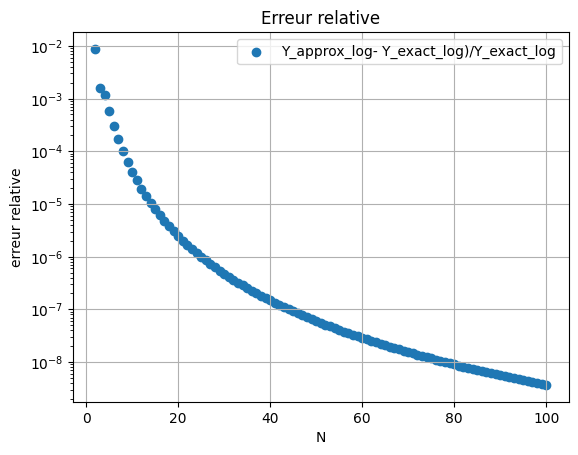

In [ ]:
#difference relative

NN = np.arange(2, 101)
Y_exact_log = [Z_N_exact_log(n) for n in NN]
Y_approx_log = [Z_N_approx_log(n) for n in NN]
Y_integrale_log = [Z_N_integral_log(n) for n in NN]

err_relative = [np.abs(Y_approx_log[i]- Y_exact_log[i])/Y_exact_log[i] for i in range(len(Y_exact_log))]

plt.scatter(NN, err_relative, label='(Y_approx_log- Y_exact_log)/Y_exact_log')
plt.xlabel('N')
plt.yscale('log')
plt.ylabel('erreur relative')
plt.title('Erreur relative')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print('différence entre approx et exact pour N = 5', np.abs(Z_N_approx_log(5)-Z_N_exact_log(5)))

différence entre appox et exact pour N = 5 0.002117156889970495


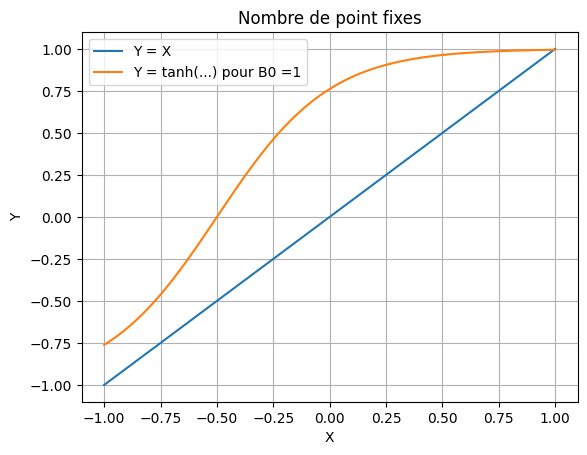

In [ ]:
#determiner le nombre de solutions de l'equation y = tanh(J0 beta y + B0 beta) = g(y)
T = 1
J0 = 2
B0 = 1

X = np.linspace(-1+10**(-12), 1- 10**(-12), 1000)
Y = np.tanh(J0*X/T+B0/T)

plt.plot(X, X, label='Y = X')
plt.plot(X, Y, label=f'Y = tanh(...) pour B0 ={B0}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Nombre de point fixes y = g(y)')
plt.legend()
plt.grid(True)
plt.show()

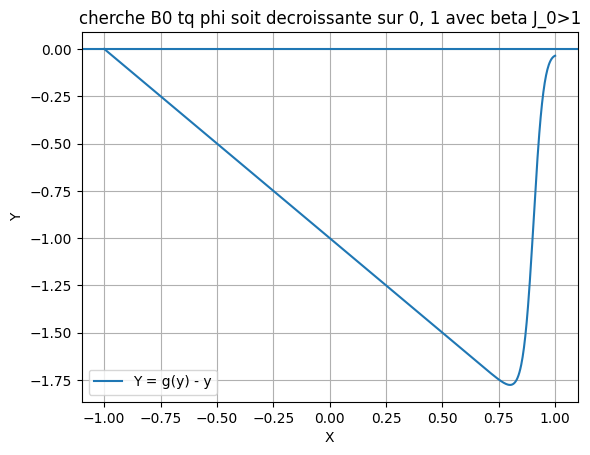

In [ ]:
#plot g(y)-y

T = 1
J0 = 21
B0 = 19

X = np.linspace(-1, 1, 1000)
Y = np.tanh(J0*X/T - B0/T) - X

plt.plot(X, Y, label='Y = g(y) - y')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('cherche B0 tq phi soit decroissante sur ]0, 1[ avec  J_0>T')
#depend du J_0, beta, en tout cas quand B est grand (devant J_0??), c'est negatif
plt.axhline(y = 0)
plt.legend()
plt.grid(True)
plt.show()

C:\Users\apeti\AppData\Local\Temp\ipykernel_20192\1973701689.py:2: RuntimeWarning: invalid value encountered in arctanh
  Y = np.arctanh(X)


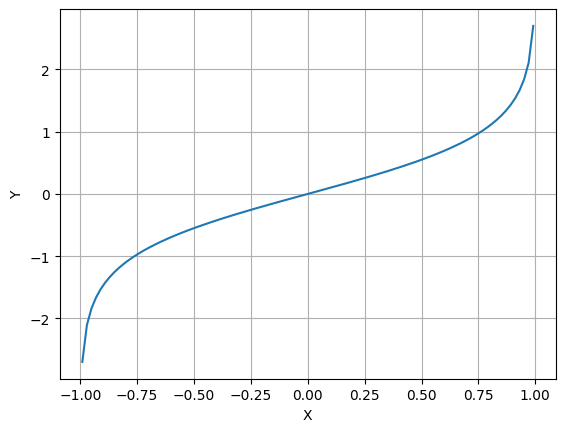

In [ ]:
#a quoi ressemble arctanh
X = np.linspace(-10, 10, 1000)
Y = np.arctanh(X)

plt.plot(X, Y)
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()